<a href="https://colab.research.google.com/github/KarlyHdzC/Mineria_de_datos/blob/main/Copia_de_Miner%C3%ADa_de_datos_8_2_Kmeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### Generación de datos aleatorios para análisis

En esta celda estamos generando un conjunto de datos sintéticos que usaremos para practicar técnicas de minería de datos.

- `np.random.seed(0)`: Establece una semilla aleatoria para que los resultados sean reproducibles. Es decir, cada vez que ejecutes el código obtendrás los mismos números aleatorios.

- `n_samples = 100`: Definimos que queremos generar 100 datos.

- `x = np.random.rand(n_samples)` y `y = np.random.rand(n_samples)`: Generamos dos arreglos de 100 números aleatorios cada uno, con valores entre 0 y 1. Estos representarán dos variables (o características) independientes.

- `data = np.column_stack((x, y))`: Combinamos las dos variables `x` e `y` en una sola estructura de datos con dos columnas y 100 filas. Así formamos un dataset de 100 puntos bidimensionales que podemos usar, por ejemplo, para aplicar clustering o visualizaciones.

Este tipo de datos sintéticos es útil para probar algoritmos sin depender de bases de datos reales.

In [2]:
# Generar datos aleatorios
np.random.seed(0)  # Para reproducibilidad
n_samples = 100
x = np.random.rand(n_samples)
y = np.random.rand(n_samples)

# Combinar las características en un array
data = np.column_stack((x, y))

# Mostrar los primeros 5 datos del arreglo
print(data[:5])


[[0.5488135  0.67781654]
 [0.71518937 0.27000797]
 [0.60276338 0.73519402]
 [0.54488318 0.96218855]
 [0.4236548  0.24875314]]


### Estandarización de los datos

En esta celda estamos aplicando un paso clave en la preparación de datos: la **estandarización**.

- `scaler = StandardScaler()`: Creamos un objeto de la clase `StandardScaler` de `sklearn`. Esta herramienta transforma los datos para que cada característica tenga media 0 y desviación estándar 1.

- `data_scaled = scaler.fit_transform(data)`: Ajustamos el `scaler` a nuestros datos (`fit`) y luego transformamos los datos (`transform`). Esto se hace en un solo paso con `fit_transform`.

¿Por qué es importante estandarizar?
Muchas técnicas de minería de datos (como K-means, PCA, etc.) se ven afectadas por la escala de las variables. Si una variable tiene un rango mucho mayor que otra, puede dominar el análisis. Estandarizar asegura que todas las variables tengan la misma importancia.

In [3]:
# Estandarizar los datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


### Aplicación del algoritmo K-Means

Aquí estamos utilizando el algoritmo **K-Means**, una técnica no supervisada muy común en minería de datos para agrupar puntos en clústeres según su similitud.

- `kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)`:
  - Creamos el modelo K-Means con 3 clústeres.
  - `init='k-means++'` mejora la selección inicial de los centros para una convergencia más rápida.
  - `random_state=42` asegura resultados reproducibles.

- `kmeans.fit(data_scaled)`: Entrenamos el modelo con nuestros datos estandarizados.

- `labels = kmeans.labels_`: Obtenemos la etiqueta de clúster asignada a cada punto. Estas etiquetas indican a qué grupo pertenece cada observación.

- `centroids = kmeans.cluster_centers_`: Obtenemos las coordenadas de los centros de cada clúster en el espacio estandarizado.

Este paso es fundamental para identificar patrones o agrupamientos naturales dentro de los datos.


In [4]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(data_scaled)

# Obtener las etiquetas de los clusters
labels = kmeans.labels_

# Obtener los centros de los clusters
centroids = kmeans.cluster_centers_


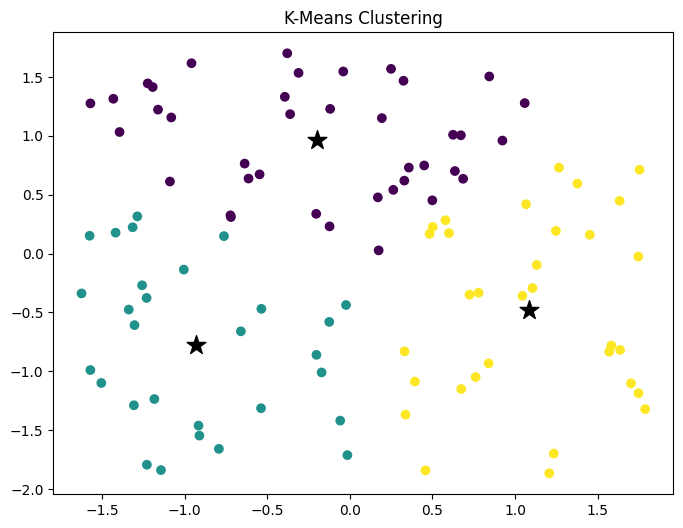

In [5]:
# Visualizar los clusters usando matplotlibs
# https://matplotlib.org/
plt.figure(figsize=(8, 6))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='*', s=200)
plt.title('K-Means Clustering')
plt.show()


## Ejemplo 2

In [6]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
import seaborn as sns

### Establecer estilos para las gráficas

Antes de visualizar los resultados del clustering, configuramos el estilo de nuestras gráficas para que sean más claras y estéticamente agradables:

- `plt.style.use('ggplot')`: Usamos el estilo `'ggplot'` de `matplotlib`, que aplica una paleta de colores y fondo similares al software R, haciendo las gráficas más limpias y fáciles de interpretar.

- `sns.set_palette("colorblind")`: Con esta línea ajustamos la paleta de colores de `seaborn` para que sea amigable para personas con daltonismo, lo que mejora la accesibilidad visual de nuestras gráficas.

Estas configuraciones no afectan el análisis en sí, pero hacen que nuestras visualizaciones sean más efectivas para comunicar resultados.


In [7]:
# Usamos estilos disponibles en matplotlib
plt.style.use('ggplot')  # Este estilo está disponible por defecto
sns.set_palette("colorblind")

### Generación de un conjunto de datos con clústeres definidos

Ahora vamos a crear un conjunto de datos sintético que tenga **3 clústeres bien definidos**, ideal para probar y visualizar algoritmos de agrupamiento como K-Means.

- `X, y_true = make_blobs(...)`: Usamos la función `make_blobs` de `sklearn.datasets` para generar datos artificiales.

  - `n_samples=300`: Se generan 300 puntos de datos.
  - `centers=3`: Se crean 3 grupos (clústeres) distintos.
  - `cluster_std=0.60`: Define qué tan compactos están los puntos dentro de cada clúster (a menor valor, más juntos).
  - `random_state=42`: Asegura que los datos generados sean los mismos cada vez que se ejecuta el código.

`X` contiene las coordenadas de los puntos, mientras que `y_true` contiene las etiquetas reales de los clústeres, que solo se usan para evaluar visualmente el desempeño del algoritmo (no son necesarias para K-Means).


In [8]:
# Crearemos un conjunto de datos con 3 clusters bien definidos
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

In [9]:
# Convertimos a DataFrame para mejor manipulación
df = pd.DataFrame(X, columns=['Característica_1', 'Característica_2'])

df.head()

,Característica_1,Característica_2
0,-7.155244,-7.390016
1,-7.395875,-7.110843
2,-2.015671,8.281780
3,4.509270,2.632436
4,-8.102502,-7.484961


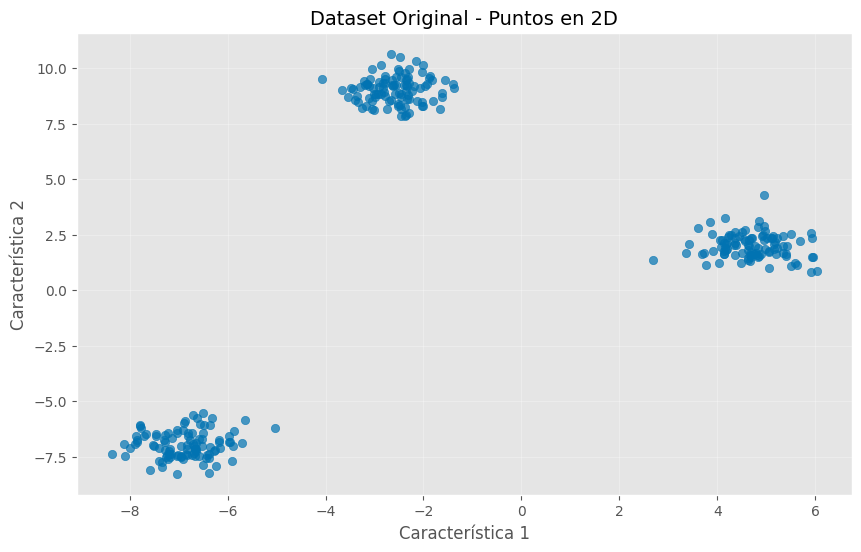

In [10]:
# 2. Visualizamos los datos originales
plt.figure(figsize=(10, 6))
plt.scatter(df['Característica_1'], df['Característica_2'], alpha=0.7)
plt.title('Dataset Original - Puntos en 2D', fontsize=14)
plt.xlabel('Característica 1', fontsize=12)
plt.ylabel('Característica 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

X_scaled = scaler.fit_transform(X) realiza dos operaciones en una sola línea:

fit(): Calcula la media y desviación estándar de cada columna en X
transform(): Aplica la transformación restando la media y dividiendo por la desviación estándar


La operación matemática es: X_scaled = (X - μ) / σ

In [11]:
# 3. Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=['Característica_1', 'Característica_2'])

### Determinación del número óptimo de clústeres con el método del codo y la puntuación de silueta

En esta celda buscamos encontrar el número ideal de clústeres (`k`) para aplicar K-Means. Utilizamos dos métricas comunes:

1. **Inercia (inertia)**: Mide qué tan compactos están los clústeres. Es la suma de las distancias cuadradas de cada punto a su centroide. Mientras más baja, mejor (hasta cierto punto).
2. **Silhouette Score**: Evalúa qué tan bien se agrupan los puntos. Toma valores entre -1 y 1, donde valores cercanos a 1 indican una mejor separación entre clústeres.

#### Explicación del código:

- `k_range = range(2, 10)`: Probamos valores de `k` desde 2 hasta 9.

- `for k in k_range`: Iteramos sobre cada valor de `k`.

- `kmeans = KMeans(...)`: Creamos y ajustamos el modelo K-Means para ese valor de `k`.

- `inertias.append(kmeans.inertia_)`: Guardamos la inercia del modelo entrenado.

- `labels = kmeans.labels_`: Obtenemos las etiquetas asignadas por K-Means.

- `silhouette_scores.append(...)`: Calculamos y almacenamos el *Silhouette Score* usando las etiquetas y los datos estandarizados.

Estas métricas las usaremos en la siguiente celda para visualizar cuál valor de `k` produce la mejor agrupación. El objetivo es identificar el "codo" de la curva de inercia (donde deja de bajar significativamente) y/o el valor de `k` con mayor *Silhouette Score*.


In [12]:
# 4. Determinamos el número óptimo de clusters usando el método del codo
inertias = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

    # Calculamos también el silhouette score para cada k
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))

([<matplotlib.axis.XTick at 0x79e7f88d16a0>,
 [Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

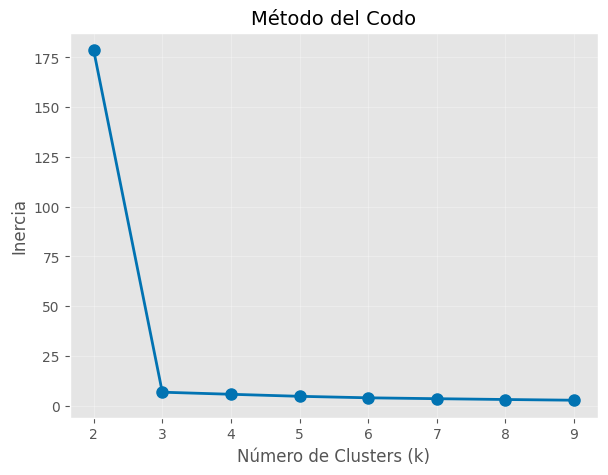

In [13]:
# Gráfica del método del codo
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'o-', markersize=8, linewidth=2)
plt.title('Método del Codo', fontsize=14)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

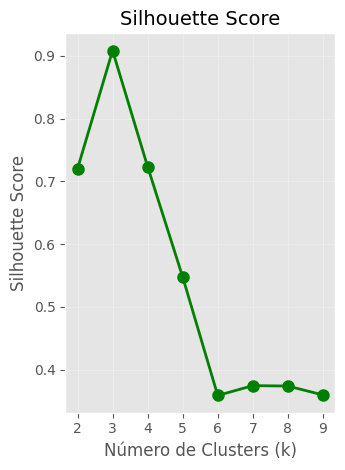

In [14]:
# Gráfica del silhouette score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'o-', markersize=8, linewidth=2, color='green')
plt.title('Silhouette Score', fontsize=14)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

plt.tight_layout()
plt.show()

### Aplicación de K-Means con el número óptimo de clústeres (k = 3)

Una vez identificado que **k = 3** es el número adecuado de clústeres (por el método del codo o el *Silhouette Score*), aplicamos el algoritmo K-Means con ese valor.

- `kmeans = KMeans(...)`: Creamos el modelo de K-Means especificando 3 clústeres y un `random_state` para resultados reproducibles.

- `kmeans.fit(X_scaled)`: Entrenamos el modelo con los datos estandarizados.

- `clusters = kmeans.labels_`: Obtenemos las etiquetas de clúster asignadas a cada punto. Cada valor indica a cuál grupo pertenece un punto en el espacio.

- `df['Cluster'] = clusters`: Añadimos una nueva columna al DataFrame original `df`, en la que se guarda la etiqueta del clúster para cada punto.

Esto nos permitirá visualizar o analizar los datos sabiendo a qué grupo pertenece cada observación, facilitando la interpretación de patrones en los datos.


In [15]:
# 5. Aplicamos K-means con el número óptimo de clusters (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
clusters = kmeans.labels_

# Agregamos las etiquetas de cluster al DataFrame
df['Cluster'] = clusters


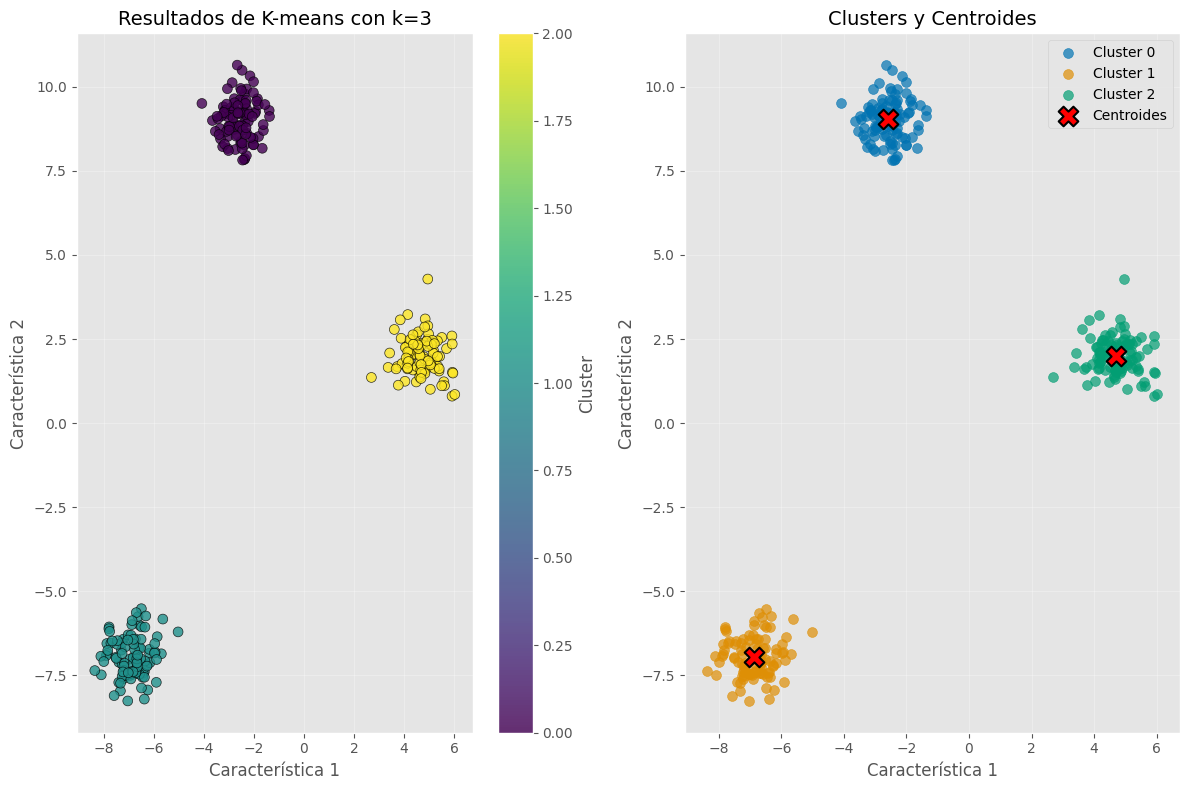

In [16]:
# 6. Visualizamos los clusters resultantes
plt.figure(figsize=(12, 8))

# Gráfica de los clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(df['Característica_1'], df['Característica_2'],
                     c=df['Cluster'], cmap='viridis',
                     s=50, alpha=0.8, edgecolor='k', linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title('Resultados de K-means con k=3', fontsize=14)
plt.xlabel('Característica 1', fontsize=12)
plt.ylabel('Característica 2', fontsize=12)
plt.grid(True, alpha=0.3)

# Gráfica con centroides
plt.subplot(1, 2, 2)
for i in range(3):
    plt.scatter(df[df['Cluster'] == i]['Característica_1'],
                df[df['Cluster'] == i]['Característica_2'],
                s=50, alpha=0.7, label=f'Cluster {i}')

# Agregamos los centroides
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, marker='X', c='red',
            edgecolor='k', linewidth=1.5, label='Centroides')

plt.title('Clusters y Centroides', fontsize=14)
plt.xlabel('Característica 1', fontsize=12)
plt.ylabel('Característica 2', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
# 7. Análisis de los clusters resultantes
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster').agg({
    'Característica_1': ['mean', 'std', 'min', 'max'],
    'Característica_2': ['mean', 'std', 'min', 'max']
})

print("Estadísticas por cluster:")
print(cluster_stats)

Estadísticas por cluster:
        Característica_1                               Característica_2  \
                    mean       std       min       max             mean   
Cluster                                                                   
0              -2.583619  0.521776 -4.081045 -1.377486         9.031856   
1              -6.882174  0.611887 -8.362614 -5.032299        -6.942434   
2               4.704214  0.623869  2.695118  6.028674         1.995624   

                                        
              std       min        max  
Cluster                                 
0        0.599136  7.821745  10.646388  
1        0.597805 -8.261262  -5.517694  
2        0.555970  0.801917   4.284809  


<Figure size 1200x800 with 0 Axes>

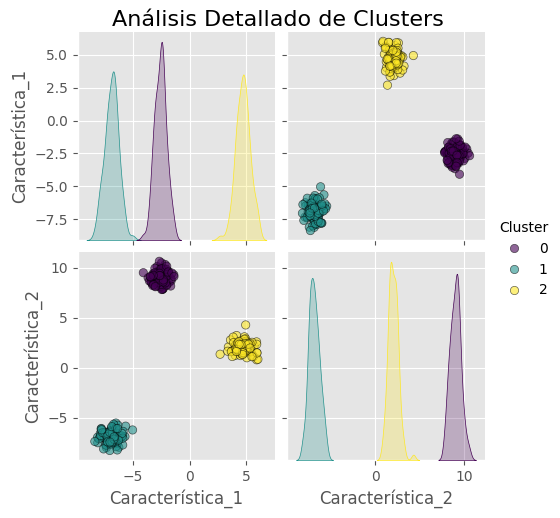

In [18]:
# 8. Visualización con Seaborn para un análisis más detallado
plt.figure(figsize=(12, 8))

# Pairplot detallado
sns.pairplot(df, hue='Cluster', palette='viridis', diag_kind='kde',
             plot_kws={'alpha': 0.6, 'edgecolor': 'k', 'linewidth': 0.5})
plt.suptitle('Análisis Detallado de Clusters', y=1.02, fontsize=16)
plt.show()

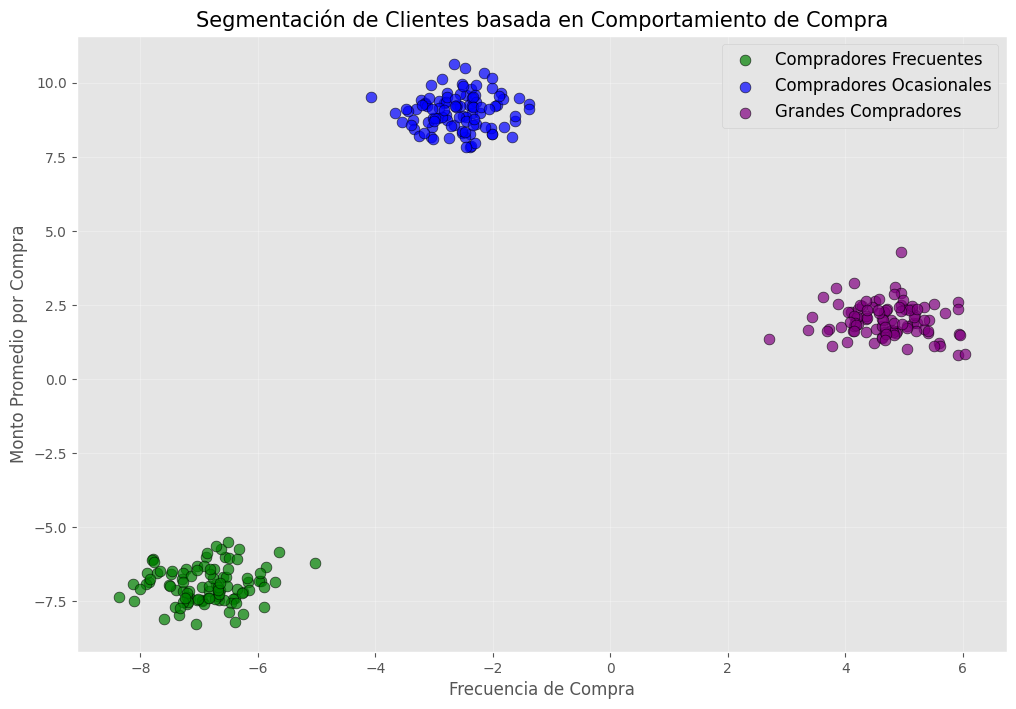

In [19]:
# 9. Aplicación Práctica: Imaginemos que estos datos representan
# comportamientos de compra de clientes (Frecuencia vs Monto)
# Renombramos columnas para esta interpretación
df_business = df.copy()
df_business.columns = ['Frecuencia_Compra', 'Monto_Promedio', 'Segmento']
df_business['Segmento'] = df_business['Segmento'].map({
    0: 'Compradores Ocasionales',
    1: 'Compradores Frecuentes',
    2: 'Grandes Compradores'
})

# Visualización orientada al negocio
plt.figure(figsize=(12, 8))
for segmento, color in zip(df_business['Segmento'].unique(), ['green', 'blue', 'purple']):
    subset = df_business[df_business['Segmento'] == segmento]
    plt.scatter(subset['Frecuencia_Compra'], subset['Monto_Promedio'],
                s=60, c=color, label=segmento, alpha=0.7,
                edgecolor='k', linewidth=0.5)

plt.title('Segmentación de Clientes basada en Comportamiento de Compra', fontsize=15)
plt.xlabel('Frecuencia de Compra', fontsize=12)
plt.ylabel('Monto Promedio por Compra', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
df_business.head()

,Frecuencia_Compra,Monto_Promedio,Segmento
0,-7.155244,-7.390016,Compradores Frecuentes
1,-7.395875,-7.110843,Compradores Frecuentes
2,-2.015671,8.281780,Compradores Ocasionales
3,4.509270,2.632436,Grandes Compradores
4,-8.102502,-7.484961,Compradores Frecuentes


In [21]:
# 10. Conclusión y recomendaciones para cada segmento
print("\nConclusiones y Recomendaciones por Segmento:")
for segmento in df_business['Segmento'].unique():
    stats = df_business[df_business['Segmento'] == segmento].describe()
    frecuencia = stats['Frecuencia_Compra']['mean']
    monto = stats['Monto_Promedio']['mean']

    print(f"\n{segmento}:")
    print(f"- Frecuencia promedio: {frecuencia:.2f}")
    print(f"- Monto promedio: {monto:.2f}")

    if segmento == 'Compradores Ocasionales':
        print("Recomendación: Aumentar frecuencia con promociones por tiempo limitado")
    elif segmento == 'Compradores Frecuentes':
        print("Recomendación: Aumentar ticket promedio con cross-selling")
    else:
        print("Recomendación: Programa de fidelización premium para retención")


Conclusiones y Recomendaciones por Segmento:

Compradores Frecuentes:
- Frecuencia promedio: -6.88
- Monto promedio: -6.94
Recomendación: Aumentar ticket promedio con cross-selling

Compradores Ocasionales:
- Frecuencia promedio: -2.58
- Monto promedio: 9.03
Recomendación: Aumentar frecuencia con promociones por tiempo limitado

Grandes Compradores:
- Frecuencia promedio: 4.70
- Monto promedio: 2.00
Recomendación: Programa de fidelización premium para retención


## Ejemplo 3: datos de ventas a partir de los préstamos de un banco

### Información del dataset

Encuentra toda la documentación del dataset en:

---
https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kneed

In [ ]:
# Paso 1: Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator

# Paso 2: Cargamos el dataset
file_path = "/content/drive/MyDrive/Anáhuac - Mineria de Datos/Libretas/data/sales_data_sample_bank.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1")  # Ruta en Colab

# Paso 3: Exploramos los primeros datos
df.head()


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


### Selección y normalización de características numéricas para clustering

Antes de aplicar K-Means en un conjunto de datos real, debemos seleccionar las variables relevantes y asegurarnos de que estén en la misma escala.

#### Paso 4: Seleccionamos las columnas numéricas

- `features = ["QUANTITYORDERED", "PRICEEACH", "SALES"]`: Indicamos las columnas numéricas que usaremos para agrupar (puedes modificarlas según tu dataset).

- `X = df[features].dropna()`: Creamos un nuevo DataFrame `X` con solo esas columnas, y eliminamos las filas que contengan valores nulos para evitar errores en el análisis.

#### Paso 5: Normalizamos los datos

- `scaler = StandardScaler()`: Creamos un objeto de estandarización de `sklearn`.

- `X_scaled = scaler.fit_transform(X)`: Calculamos la media y desviación estándar de cada variable y transformamos los datos. Esto asegura que todas las variables tengan la misma importancia al aplicar K-Means.

Este preprocesamiento es clave para garantizar que el algoritmo funcione correctamente y los resultados sean significativos.


In [ ]:
# Paso 4: Seleccionamos las columnas numéricas para aplicar K-Means
# (Modifica aquí según tus columnas)
features = ["QUANTITYORDERED", "PRICEEACH", "SALES"]
X = df[features].dropna()  # Eliminamos filas con valores nulos

# Paso 5: Normalizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


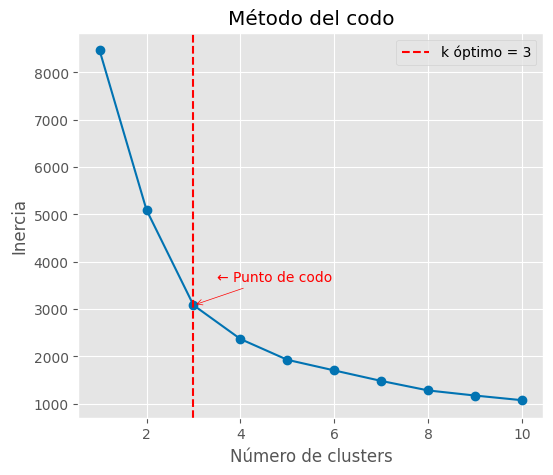

In [ ]:
# Paso 6: Usamos el método del codo para determinar el número óptimo de clusters
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Detectar automáticamente el punto de codo
kneedle = KneeLocator(K, inertia, curve="convex", direction="decreasing")
k_optimo = kneedle.knee

# Graficar
plt.figure(figsize=(6, 5))
plt.plot(K, inertia, marker='o')
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.annotate("← Punto de codo", xy=(k_optimo, inertia[k_optimo-1]), xytext=(k_optimo+0.5, inertia[k_optimo-1]+500),
             arrowprops=dict(arrowstyle="->", color='red'), color='red')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Paso 7: Aplicamos K-Means con el número óptimo de clusters (por ejemplo, 3)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Paso 8: Agregamos los clusters al DataFrame
df_clusters = X.copy()
df_clusters["Cluster"] = clusters
df_clusters.head()


,QUANTITYORDERED,PRICEEACH,SALES,Cluster
0,30,95.70,2871.00,2
1,34,81.35,2765.90,2
2,41,94.74,3884.34,1
3,45,83.26,3746.70,1
4,49,100.00,5205.27,1


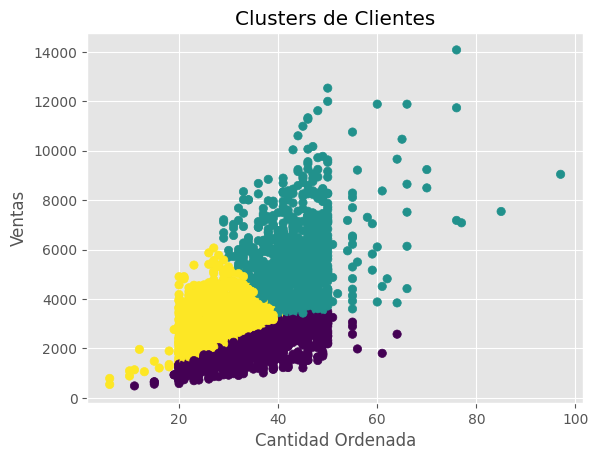

In [ ]:
# Paso 9: Visualizamos los clusters (usando solo dos variables para el gráfico)
plt.scatter(df_clusters["QUANTITYORDERED"], df_clusters["SALES"], c=df_clusters["Cluster"], cmap="viridis")
plt.xlabel("Cantidad Ordenada")
plt.ylabel("Ventas")
plt.title("Clusters de Clientes")
plt.grid(True)
plt.show()


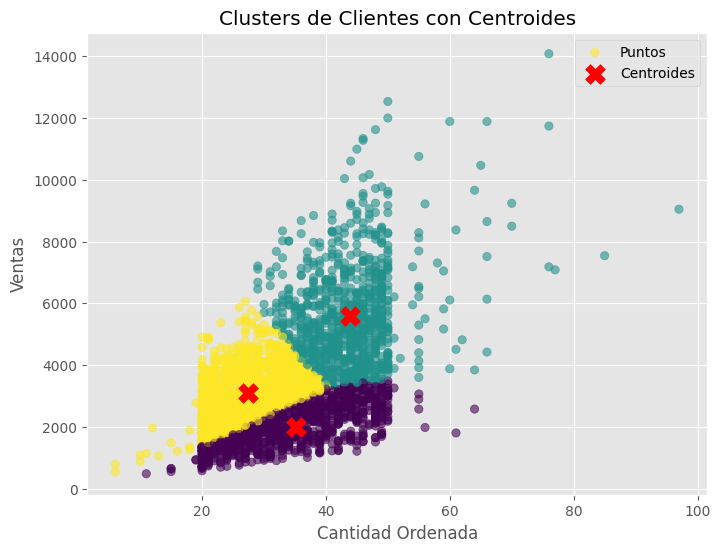

In [ ]:
# Paso 10: Visualizamos los clusters con sus centroides
plt.figure(figsize=(8, 6))

# Gráfico de dispersión con color por cluster
plt.scatter(df_clusters["QUANTITYORDERED"], df_clusters["SALES"], c=df_clusters["Cluster"], cmap="viridis", alpha=0.6, label="Puntos")

# Invertimos la escala para regresar los centroides a su forma original
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Dibujamos los centroides
plt.scatter(centroids[:, features.index("QUANTITYORDERED")],
            centroids[:, features.index("SALES")],
            c='red', marker='X', s=200, label='Centroides')

plt.xlabel("Cantidad Ordenada")
plt.ylabel("Ventas")
plt.title("Clusters de Clientes con Centroides")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Ya tenemos esto:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Lo pasamos a un DataFrame para facilitar la interpretación
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df["Cluster"] = range(len(centroids_df))
centroids_df


,QUANTITYORDERED,PRICEEACH,SALES,Cluster
0,35.125993,57.130216,2009.829955,0
1,43.843612,96.623910,5581.559273,1
2,27.380077,94.876054,3088.890561,2


## 🧠 Interpretación de Clusters (K-Means)

| Cluster | QUANTITYORDERED | PRICEEACH | SALES  | Descripción |
|---------|------------------|------------|--------|-------------|
| **0**   | 35.1              | 57.13      | 2009.8 | Clientes de volumen medio que compran productos más económicos. Generan un nivel moderado de ventas. |
| **1**   | 43.8              | 96.62      | 5581.5 | Clientes premium. Compran productos caros y en grandes cantidades. Son responsables de las ventas más altas. |
| **2**   | 27.3              | 94.87      | 3088.9 | Clientes de productos costosos pero con menor volumen de compra. Generan buen ingreso por transacción, aunque menos volumen global. |

## 🎯 Recomendaciones Estratégicas

| Cluster | Estrategia de Marketing |
|---------|--------------------------|
| **0**   | Incentivar el aumento de volumen con promociones o descuentos por cantidad. |
| **1**   | Mantener con programas de lealtad, servicio personalizado y recompensas VIP. |
| **2**   | Promover productos premium y experiencias exclusivas que justifiquen el valor unitario alto. |


## Ejemplo 4 - Datos Bancarios

In [ ]:
file_path = "/content/drive/MyDrive/Anáhuac - Mineria de Datos/Libretas/data/datos-bancarios.csv"
df_credit = pd.read_csv(file_path, encoding="ISO-8859-1")  # Ruta en Colab

df_credit.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


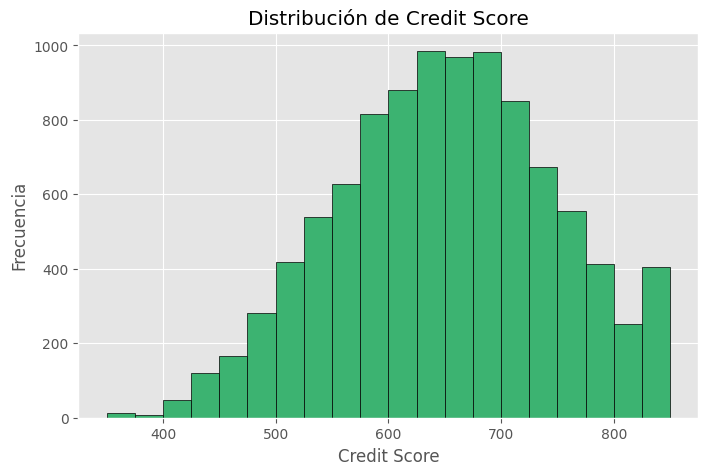

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_credit["CreditScore"].dropna(), bins=20, color="mediumseagreen", edgecolor="black")
plt.title("Distribución de Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()


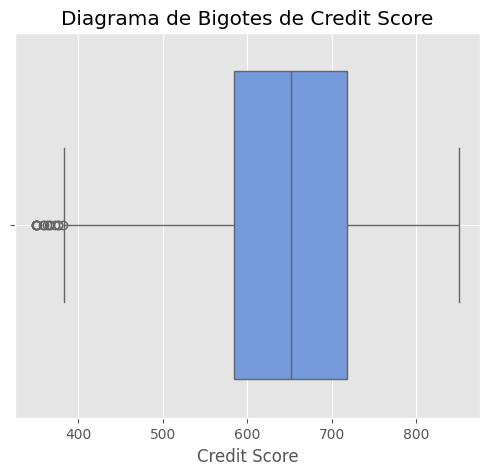

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.boxplot(x=df_credit["CreditScore"], color="cornflowerblue")
plt.title("Diagrama de Bigotes de Credit Score")
plt.xlabel("Credit Score")
plt.grid(True)
plt.show()


## 🧾 Rangos de Credit Score

| Rango de Credit Score | Interpretación                       |
|------------------------|--------------------------------------|
| **300 - 579**          | Muy bajo. Alto riesgo de impago. Difícil acceder a crédito. |
| **580 - 669**          | Bajo. Riesgo moderado-alto. Posibles restricciones al crédito. |
| **670 - 739**          | Aceptable. Riesgo promedio. Acceso razonable a productos financieros. |
| **740 - 799**          | Bueno. Bajo riesgo. Buen historial crediticio. |
| **800 - 850**          | Excelente. Muy bajo riesgo. Acceso a mejores tasas y condiciones. |

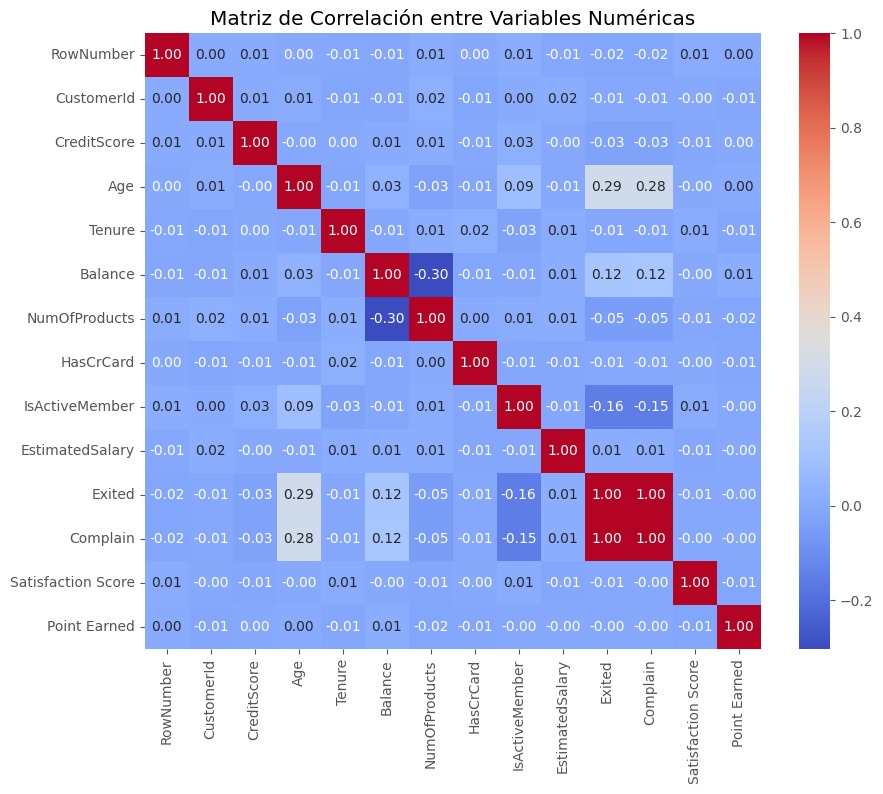

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las variables numéricas
numeric_df = df_credit.select_dtypes(include=["int64", "float64"])

# Calculamos la matriz de correlación
correlation_matrix = numeric_df.corr()

# Mostramos como heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()


💡 ¿Qué variables usar con CreditScore?
Según la matriz de correlación, las variables numéricas que tienen algo de relación con el comportamiento del cliente (Exited, Complain, Age) y no son identificadores, podrían ser útiles.

Podemos usar:

* CreditScore

* Age (edad)

* Balance (saldo)

* IsActiveMember (actividad en el banco)

* Exited (si abandonó o no el banco, para análisis posterior)

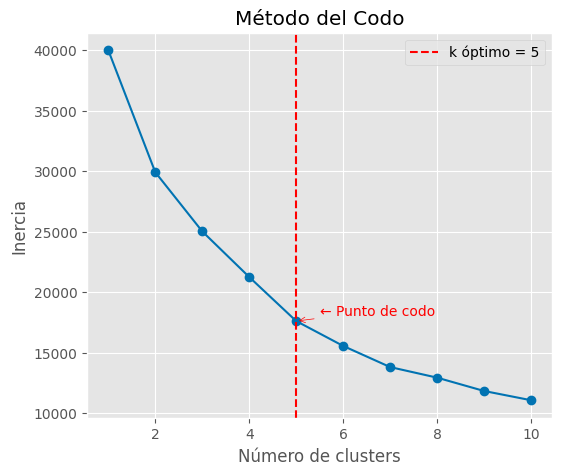

In [ ]:
# Paso 1: Selección de variables relevantes
features = ["CreditScore", "Age", "Balance", "IsActiveMember"]
X = df_credit[features].dropna()

# Paso 2: Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Paso 3: Método del Codo con detección automática
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Detección del punto de codo
kneedle = KneeLocator(K, inertia, curve="convex", direction="decreasing")
k_optimo = kneedle.knee

# Paso 4: Gráfico del método del codo
plt.figure(figsize=(6, 5))
plt.plot(K, inertia, marker='o')
plt.axvline(x=k_optimo, color='red', linestyle='--', label=f'k óptimo = {k_optimo}')
plt.annotate("← Punto de codo",
             xy=(k_optimo, inertia[k_optimo - 1]),
             xytext=(k_optimo + 0.5, inertia[k_optimo - 1] + 500),
             arrowprops=dict(arrowstyle="->", color='red'),
             color='red')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.grid(True)
plt.legend()
plt.show()


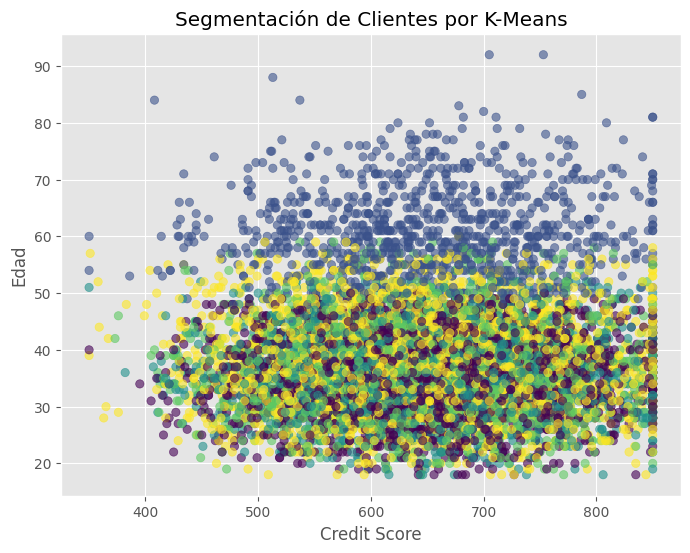

In [ ]:
# Supongamos que eliges k = 3
kmeans = KMeans(n_clusters=5, random_state=42)
df_credit["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualizamos clusters por CreditScore y Age
plt.figure(figsize=(8, 6))
plt.scatter(df_credit["CreditScore"], df_credit["Age"], c=df_credit["Cluster"], cmap="viridis", alpha=0.6)
plt.xlabel("Credit Score")
plt.ylabel("Edad")
plt.title("Segmentación de Clientes por K-Means")
plt.grid(True)
plt.show()


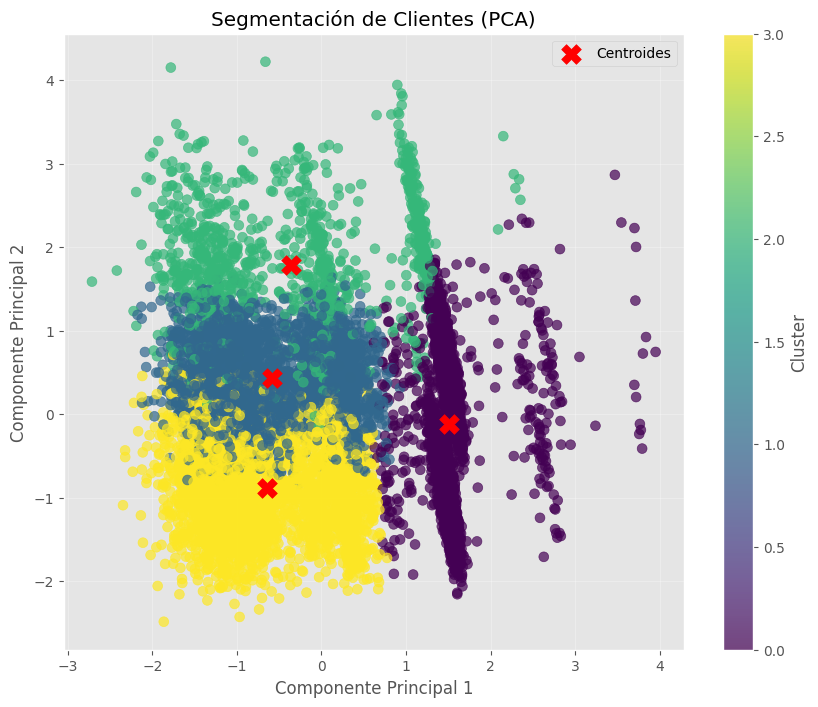

Características promedio por cluster:
         CreditScore        Age        Balance  NumOfProducts  IsActiveMember  \
Cluster                                                                         
0         650.556200  35.922045    9471.841037       2.127991        0.488397   
1         653.744894  35.349256  107634.579318       1.293527        1.000000   
2         650.724453  60.020073   75526.628969       1.435219        0.834854   
3         647.587043  37.531164  105926.334142       1.265889        0.000000   

         Satisfaction Score  
Cluster                      
0                  3.002538  
1                  3.031845  
2                  3.037409  
3                  2.999386  


In [ ]:
# Preprocesamiento de datos
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables relevantes para la segmentación
features = ['CreditScore', 'Age', 'Balance', 'NumOfProducts',
            'IsActiveMember', 'Satisfaction Score']

# Para variables categóricas, usa pd.get_dummies()
# df_with_dummies = pd.get_dummies(df_credit, columns=['Geography', 'Card Type'], drop_first=True)
# features.extend([col for col in df_with_dummies.columns if 'Geography_' in col or 'Card Type_' in col])

# Crear dataset para clustering
X = df_credit[features].copy()

# Manejar valores nulos si existen
X.fillna(X.mean(), inplace=True)

# Normalizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar K-means con el número óptimo de clusters (por ejemplo, 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_credit["Cluster"] = kmeans.fit_predict(X_scaled)

# Visualizar los resultados (ahora en un espacio multidimensional)
# Para visualizar en 2D, podemos usar PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualizar clusters en espacio PCA
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_credit["Cluster"],
                     cmap="viridis", alpha=0.7, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Segmentación de Clientes (PCA)')
plt.grid(True, alpha=0.3)

# Añadir los centroides (transformados a espacio PCA)
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200,
            color='red', label='Centroides')
plt.legend()
plt.show()

# Análisis de los clusters
cluster_summary = df_credit.groupby('Cluster')[features].mean()
print("Características promedio por cluster:")
print(cluster_summary)

# Interpretación de Clusters - Segmentación de Clientes Bancarios

| Cluster | Nombre del Segmento | Características Clave | Perfil Demográfico | Comportamiento Financiero | Estrategia Recomendada |
|---------|---------------------|------------------------|---------------------|---------------------------|------------------------|
| **0** | **Multiproducto de Balance Bajo** | • Balance: ~9,471<br>• Productos: 2.13<br>• Actividad: 48.8%<br>• Satisfacción: 3.00/5 | Adultos jóvenes (35.9 años) en etapa inicial de vida financiera | Utilizan múltiples productos bancarios pero mantienen saldos bajos | **Desarrollo de valor**:<br>• Incentivos para incrementar depósitos<br>• Programas de ahorro automático<br>• Educación financiera |
| **1** | **Activos de Alto Valor** | • Balance: ~107,634<br>• Productos: 1.29<br>• Actividad: 100%<br>• Satisfacción: 3.03/5 | Clientes jóvenes (35.3 años) económicamente establecidos | Alta actividad y saldos elevados con pocos productos | **Cross-selling y fidelización**:<br>• Ofertas de productos premium<br>• Programas de lealtad<br>• Asesoramiento financiero personalizado |
| **2** | **Senior Estables** | • Balance: ~75,526<br>• Productos: 1.43<br>• Actividad: 83.5%<br>• Satisfacción: 3.04/5 | Clientes mayores (60.0 años), posiblemente jubilados o pre-jubilados | Balances considerables con relación estable y duradera | **Retención y servicios específicos**:<br>• Productos para jubilación<br>• Gestión patrimonial<br>• Servicios de planificación sucesoria |
| **3** | **Inactivos de Alto Balance** | • Balance: ~105,926<br>• Productos: 1.27<br>• Actividad: 0%<br>• Satisfacción: 2.99/5 | Adultos (37.5 años) probablemente desvinculados del banco | Altos saldos pero completamente inactivos, posible riesgo de fuga | **Reactivación urgente**:<br>• Programa de recuperación<br>• Contacto directo personalizado<br>• Investigación de causas de inactividad |

## Observaciones Adicionales:
- La puntuación crediticia (CreditScore) es similar en todos los clusters (~650), indicando que no es un factor diferenciador.
- La edad y el nivel de actividad son los principales factores de segmentación.
- El cluster 3 representa un riesgo significativo de pérdida de clientes con alto valor.